# Hand Poses in Kendall Shape Space

This tutorial analyzes real skeletal hand poses using Kendall shape space. A
hand is represented by $22$ joints in $\mathbb R^3$. We want to compare the
shape of a pose without letting its location, physical scale, or global
orientation dominate the result.

The data are a 52-pose subset of the SHREC'17 3D hand-gesture dataset,
distributed by the [Geomstats dataset
module](https://github.com/geomstats/geomstats/tree/master/geomstats/datasets/data/hands).
There are 25 **Grab** poses and 27 **Expand** poses. The source study is De
Smedt et al., [SHREC'17 Track: 3D Hand Gesture Recognition Using a Depth and
Skeletal Dataset](https://doi.org/10.2312/3dor.20171049).

GeoJAX vendors the two small source text files with this page, so the
documentation remains executable without downloading data at build time.

## Shape-space model

For $m$ landmarks in $\mathbb R^d$, a pre-shape is an $m\times d$ matrix $X$
satisfying

$$
\mathbf 1^\top X=0,
\qquad
\lVert X\rVert_F=1.
$$

Centering removes translation and normalization removes scale. Kendall shape
space additionally identifies $X$ and $XR$ for every $R\in SO(d)$, thereby
removing global orientation. Its distance is the spherical distance after
orientation-preserving Procrustes alignment:

$$
d([X],[Y])
=\arccos\left(\max_{R\in SO(d)}\langle X,YR\rangle_F\right).
$$

We will compute a Fréchet mean for each pose class and classify held-out hands
by their nearest intrinsic mean.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from geojax.geometry import KendallShape

## Load the landmark data

The files are the original whitespace-separated Geomstats data. Their first
rows are numeric column headers, matching the upstream loader, so we skip one
row before reshaping each pose to $22\times3$.

In [2]:
candidate_directories = [
    Path("../_static/data/hands"),
    Path("docs/_static/data/hands"),
]
data_directory = next(path for path in candidate_directories if path.exists())

raw_hands = np.loadtxt(data_directory / "hands.txt", skiprows=1).reshape(-1, 22, 3)
labels = np.loadtxt(data_directory / "labels.txt", skiprows=1, dtype=int)
label_names = {0: "Grab", 1: "Expand"}

bones = np.array(
    [
        [0, 1], [0, 2], [2, 3], [3, 4], [4, 5],
        [1, 6], [6, 7], [7, 8], [8, 9],
        [1, 10], [10, 11], [11, 12], [12, 13],
        [1, 14], [14, 15], [15, 16], [16, 17],
        [1, 18], [18, 19], [19, 20], [20, 21],
    ]
)

print("landmark array:", raw_hands.shape)
for label, name in label_names.items():
    print(f"{name:6s}: {int(np.sum(labels == label))} poses")

landmark array: (52, 22, 3)
Grab  : 25 poses
Expand: 27 poses


## Remove translation and scale

`KendallShape.project` centers every configuration and normalizes its
Frobenius norm. Rotation is not removed by choosing one permanent alignment;
it is handled by the quotient operations whenever distances and logarithms are
evaluated.

In [3]:
M = KendallShape(size=(22, 3))
hands = M.project(jnp.asarray(raw_hands))

centroid_norms = jnp.linalg.norm(jnp.mean(hands, axis=1), axis=1)
preshape_norms = jnp.linalg.norm(hands, axis=(1, 2))

print("All projected hands are regular pre-shapes:", bool(jnp.all(M.belongs(hands))))
print("Largest centroid norm:", f"{float(jnp.max(centroid_norms)):.3e}")
print("Largest unit-norm error:", f"{float(jnp.max(jnp.abs(preshape_norms - 1))):.3e}")
print("Intrinsic dimension:", M.dim)

All projected hands are regular pre-shapes: True
Largest centroid norm: 7.182e-16
Largest unit-norm error: 2.220e-16
Intrinsic dimension: 59


## Compute intrinsic group means

At a current estimate $\mu_t$, the average logarithm

$$
v_t=\frac1N\sum_{i=1}^N\operatorname{Log}_{\mu_t}(X_i)
$$

is the negative Riemannian gradient of the Fréchet objective. The Karcher
iteration

$$
\mu_{t+1}=\operatorname{Exp}_{\mu_t}(v_t)
$$

therefore moves along the intrinsic average displacement. We initialize by
Procrustes-aligning the group to one observation and projecting its ambient
average.

Every fourth observation is held out before estimating the two means. This is
a deterministic illustrative split, not a claim of benchmark performance.

In [4]:
def initial_shape_mean(points):
    reference = points[0]
    aligned = jax.vmap(lambda point: M.align(point, reference)[0])(points)
    return M.project(jnp.mean(aligned, axis=0))


def frechet_mean(points, maxiter=40, tolerance=1e-8):
    mean = initial_shape_mean(points)
    update_norms = []
    for _ in range(maxiter):
        logarithms = jax.vmap(lambda point: M.log(mean, point))(points)
        update = jnp.mean(logarithms, axis=0)
        update_norm = float(M.norm(mean, update))
        update_norms.append(update_norm)
        if update_norm < tolerance:
            break
        mean = M.exp(mean, update)
    return mean, np.asarray(update_norms)


sample_ids = np.arange(len(labels))
train_mask = sample_ids % 4 != 0
test_mask = ~train_mask

means = []
mean_histories = []
for label in (0, 1):
    group = hands[jnp.asarray(train_mask & (labels == label))]
    mean, history = frechet_mean(group)
    means.append(mean)
    mean_histories.append(history)
    print(
        f"{label_names[label]:6s}: {len(group):2d} training poses, "
        f"{len(history):2d} updates, final norm {history[-1]:.3e}"
    )

means = jnp.stack(means)
print("Distance between group means:", f"{float(M.dist(means[0], means[1])):.4f}")

Grab  : 18 training poses,  9 updates, final norm 1.804e-09
Expand: 21 training poses,  5 updates, final norm 6.849e-10
Distance between group means: 0.2602


Expand: 21 training poses,  5 updates, final norm 6.849e-10


Distance between group means: 0.2602


## Classify by the nearest mean

For each hand $X$, we compute the two intrinsic distances
$d(X,\mu_{\mathrm{Grab}})$ and $d(X,\mu_{\mathrm{Expand}})$. The smaller one
determines the predicted pose.

In [5]:
distances = jax.vmap(
    lambda hand: jax.vmap(lambda mean: M.dist(hand, mean))(means)
)(hands)
predictions = np.asarray(jnp.argmin(distances, axis=1))
test_accuracy = np.mean(predictions[test_mask] == labels[test_mask])

print(f"Held-out poses: {int(np.sum(test_mask))}")
print(f"Correct predictions: {int(np.sum(predictions[test_mask] == labels[test_mask]))}")
print(f"Held-out accuracy: {test_accuracy:.1%}")
print("\nHeld-out confusion counts (truth -> prediction)")
for truth in (0, 1):
    counts = [
        int(np.sum(test_mask & (labels == truth) & (predictions == prediction)))
        for prediction in (0, 1)
    ]
    print(f"{label_names[truth]:6s}: Grab={counts[0]:2d}, Expand={counts[1]:2d}")

Held-out poses: 13
Correct predictions: 11
Held-out accuracy: 84.6%

Held-out confusion counts (truth -> prediction)
Grab  : Grab= 5, Expand= 2
Expand: Grab= 0, Expand= 6


## Visualize poses, means, and separation

For display only, the Expand mean is aligned to the Grab mean so both use a
common orientation. The distance scatter is already quotient-invariant: points
below the diagonal are closer to Grab, and points above it are closer to
Expand. Stars mark the held-out observations.

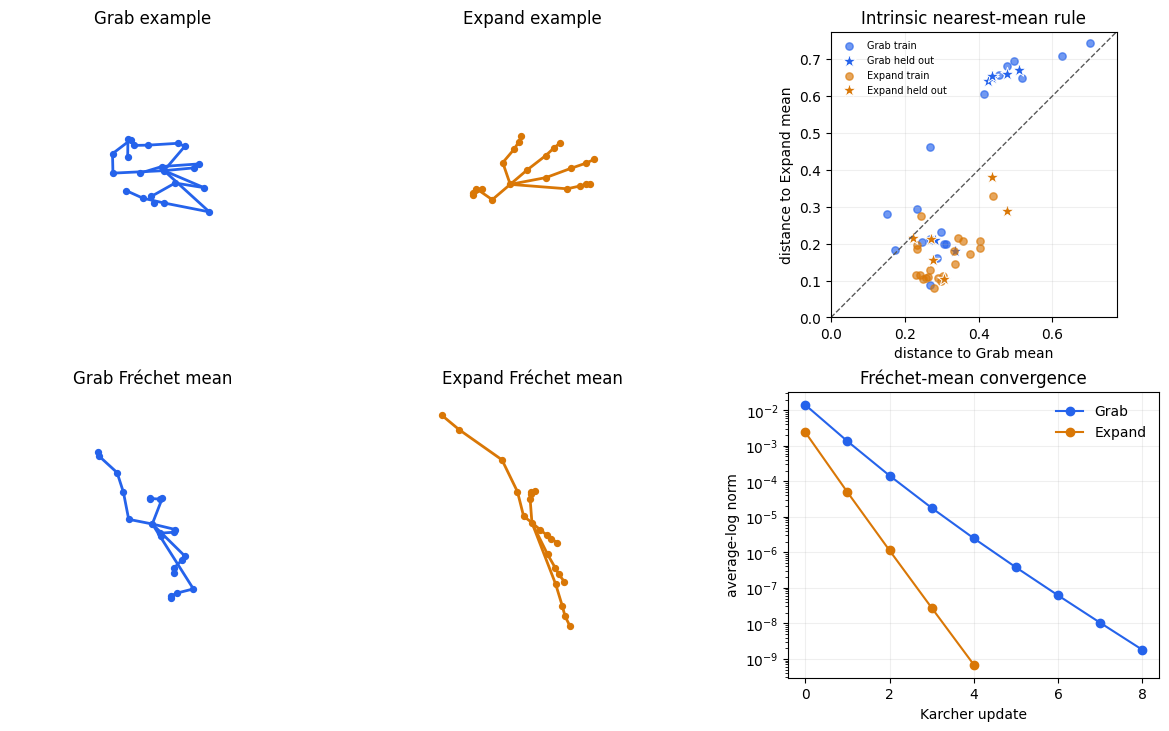

In [6]:
colors = {0: "#2563EB", 1: "#D97706"}


def draw_hand(ax, hand, color, title):
    hand = np.asarray(hand)
    for start, end in bones:
        segment = hand[[start, end]]
        ax.plot(segment[:, 0], segment[:, 1], segment[:, 2], color=color, linewidth=2.0)
    ax.scatter(hand[:, 0], hand[:, 1], hand[:, 2], color=color, s=18, depthshade=False)
    center = np.mean(hand, axis=0)
    radius = 0.55 * np.max(np.ptp(hand, axis=0))
    for setter, coordinate in zip((ax.set_xlim, ax.set_ylim, ax.set_zlim), center):
        setter(coordinate - radius, coordinate + radius)
    ax.set_title(title)
    ax.set_box_aspect((1, 1, 1), zoom=1.35)
    ax.set_axis_off()
    ax.view_init(elev=24, azim=-58)


grab_index = int(np.flatnonzero(labels == 0)[0])
expand_index = int(np.flatnonzero(labels == 1)[0])
grab_example = M.align(hands[grab_index], means[0])[0]
expand_example = M.align(hands[expand_index], means[1])[0]
aligned_expand_mean = M.align(means[1], means[0])[0]

fig = plt.figure(figsize=(12.0, 7.2), constrained_layout=True)
grid = fig.add_gridspec(2, 3)

draw_hand(fig.add_subplot(grid[0, 0], projection="3d"), grab_example, colors[0], "Grab example")
draw_hand(
    fig.add_subplot(grid[0, 1], projection="3d"),
    expand_example,
    colors[1],
    "Expand example",
)
draw_hand(fig.add_subplot(grid[1, 0], projection="3d"), means[0], colors[0], "Grab Fréchet mean")
draw_hand(
    fig.add_subplot(grid[1, 1], projection="3d"),
    aligned_expand_mean,
    colors[1],
    "Expand Fréchet mean",
)

distance_axis = fig.add_subplot(grid[0, 2])
distance_array = np.asarray(distances)
for label in (0, 1):
    training = train_mask & (labels == label)
    held_out = test_mask & (labels == label)
    distance_axis.scatter(
        distance_array[training, 0],
        distance_array[training, 1],
        color=colors[label],
        alpha=0.65,
        s=28,
        label=f"{label_names[label]} train",
    )
    distance_axis.scatter(
        distance_array[held_out, 0],
        distance_array[held_out, 1],
        color=colors[label],
        edgecolor="white",
        marker="*",
        s=105,
        linewidth=0.7,
        label=f"{label_names[label]} held out",
    )
limit = 1.04 * float(jnp.max(distances))
distance_axis.plot([0, limit], [0, limit], color="0.35", linestyle="--", linewidth=1.0)
distance_axis.set(
    xlim=(0, limit),
    ylim=(0, limit),
    xlabel="distance to Grab mean",
    ylabel="distance to Expand mean",
    title="Intrinsic nearest-mean rule",
)
distance_axis.set_aspect("equal")
distance_axis.grid(alpha=0.2)
distance_axis.legend(frameon=False, fontsize=7)

convergence_axis = fig.add_subplot(grid[1, 2])
for label, history in enumerate(mean_histories):
    convergence_axis.semilogy(
        np.arange(len(history)),
        history,
        marker="o",
        color=colors[label],
        label=label_names[label],
    )
convergence_axis.set(
    xlabel="Karcher update",
    ylabel="average-log norm",
    title="Fréchet-mean convergence",
)
convergence_axis.grid(alpha=0.2)
convergence_axis.legend(frameon=False)

plt.show()

The group means summarize the characteristic joint configuration after
translation, scale, and orientation have been removed. The classifier is
deliberately simple: it demonstrates that intrinsic distances can expose pose
information, but a serious evaluation would use repeated subject-aware splits,
uncertainty estimates, and comparisons with tangent-space or skeletal models.